In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('user_history2.csv')
df.head()

,User ID,Username,Role,Action,Timestamp,IP Address
0,14,aakash,admin,Login,2025-01-09 00:00:00,127.0.0.1
1,16,sinchina,product owner,Login,2025-01-09 00:00:00,127.0.0.1
2,19,kaushik,team member,Login,2025-01-09 00:00:00,127.0.0.1
3,17,abhinav,team member,Login,2025-01-09 00:00:00,127.0.0.1
4,18,kiran,scrum master,Login,2025-01-09 00:00:00,127.0.0.1


In [8]:
# Convert Timestamp to datetime
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
# Sort by timestamp for readability
df = df.sort_values(by="Timestamp").reset_index(drop=True)
df

,User ID,Username,Role,Action,Timestamp,IP Address
0,14,aakash,admin,Login,2025-01-09 00:00:00,127.0.0.1
1,16,sinchina,product owner,Login,2025-01-09 00:00:00,127.0.0.1
2,19,kaushik,team member,Login,2025-01-09 00:00:00,127.0.0.1
3,17,abhinav,team member,Login,2025-01-09 00:00:00,127.0.0.1
4,18,kiran,scrum master,Login,2025-01-09 00:00:00,127.0.0.1
...,...,...,...,...,...,...
195,16,sinchina,product owner,Login,2025-01-10 06:36:00,127.0.0.1
196,19,kaushik,team member,Logout,2025-01-10 06:58:00,127.0.0.1
197,18,kiran,scrum master,Login,2025-01-10 07:09:00,127.0.0.1
198,16,sinchina,product owner,Logout,2025-01-10 07:21:00,127.0.0.1


In [12]:
# Calculate session times
# Filter the dataset for Login and Logout actions
login_data = df[df["Action"] == "Login"].reset_index(drop=True)
logout_data = df[df["Action"] == "Logout"].reset_index(drop=True)

# Merge Login and Logout data on User ID, Username, and Role
merged_data = pd.merge(
    login_data,
    logout_data,
    on=["User ID", "Username", "Role", "IP Address"],
    suffixes=("_Login", "_Logout"),
)

merged_data


,User ID,Username,Role,Action_Login,Timestamp_Login,IP Address,Action_Logout,Timestamp_Logout
0,14,aakash,admin,Login,2025-01-09 00:00:00,127.0.0.1,Logout,2025-01-09 00:41:00
1,14,aakash,admin,Login,2025-01-09 00:00:00,127.0.0.1,Logout,2025-01-09 01:02:00
2,14,aakash,admin,Login,2025-01-09 00:00:00,127.0.0.1,Logout,2025-01-09 02:59:00
3,14,aakash,admin,Login,2025-01-09 00:00:00,127.0.0.1,Logout,2025-01-09 03:50:00
4,14,aakash,admin,Login,2025-01-09 00:00:00,127.0.0.1,Logout,2025-01-09 05:00:00
...,...,...,...,...,...,...,...,...
1995,18,kiran,scrum master,Login,2025-01-10 07:09:00,127.0.0.1,Logout,2025-01-10 01:05:00
1996,18,kiran,scrum master,Login,2025-01-10 07:09:00,127.0.0.1,Logout,2025-01-10 01:43:00
1997,18,kiran,scrum master,Login,2025-01-10 07:09:00,127.0.0.1,Logout,2025-01-10 03:59:00
1998,18,kiran,scrum master,Login,2025-01-10 07:09:00,127.0.0.1,Logout,2025-01-10 05:29:00


In [16]:
# Calculate session duration
merged_data["Session Time (minutes)"] = ( merged_data["Timestamp_Logout"] - merged_data["Timestamp_Login"]).dt.total_seconds() / 60

# Display the first few rows with calculated session time
merged_data[
    ["User ID", "Username", "Role", "Timestamp_Login", "Timestamp_Logout", "Session Time (minutes)"]
]

,User ID,Username,Role,Timestamp_Login,Timestamp_Logout,Session Time (minutes)
0,14,aakash,admin,2025-01-09 00:00:00,2025-01-09 00:41:00,41.0
1,14,aakash,admin,2025-01-09 00:00:00,2025-01-09 01:02:00,62.0
2,14,aakash,admin,2025-01-09 00:00:00,2025-01-09 02:59:00,179.0
3,14,aakash,admin,2025-01-09 00:00:00,2025-01-09 03:50:00,230.0
4,14,aakash,admin,2025-01-09 00:00:00,2025-01-09 05:00:00,300.0
...,...,...,...,...,...,...
1995,18,kiran,scrum master,2025-01-10 07:09:00,2025-01-10 01:05:00,-364.0
1996,18,kiran,scrum master,2025-01-10 07:09:00,2025-01-10 01:43:00,-326.0
1997,18,kiran,scrum master,2025-01-10 07:09:00,2025-01-10 03:59:00,-190.0
1998,18,kiran,scrum master,2025-01-10 07:09:00,2025-01-10 05:29:00,-100.0


In [19]:
# Ensure the data is sorted by User ID and Timestamp for proper session pairing
df = df.sort_values(by=["User ID", "Timestamp"]).reset_index(drop=True)

# Initialize a list to store session data
session_data = []

# Iterate over unique users to calculate session times
for user_id in df["User ID"].unique():
    user_data = df[df["User ID"] == user_id]
    login_time = None

    for _, row in user_data.iterrows():
        if row["Action"] == "Login":
            login_time = row["Timestamp"]
        elif row["Action"] == "Logout" and login_time:
            session_duration = (row["Timestamp"] - login_time).total_seconds() / 60  # Calculate session duration in minutes
            session_data.append({
                "User ID": user_id,
                "Username": row["Username"],
                "Role": row["Role"],
                "Login Time": login_time,
                "Logout Time": row["Timestamp"],
                "Session Duration (minutes)": session_duration
            })
            login_time = None  # Reset login_time for the next session

# Convert session data to DataFrame
session_df = pd.DataFrame(session_data)

# Display the first few rows of the session data
session_df


,User ID,Username,Role,Login Time,Logout Time,Session Duration (minutes)
0,14,aakash,admin,2025-01-09 00:00:00,2025-01-09 00:41:00,41.0
1,14,aakash,admin,2025-01-09 01:00:00,2025-01-09 01:02:00,2.0
2,14,aakash,admin,2025-01-09 02:41:00,2025-01-09 02:59:00,18.0
3,14,aakash,admin,2025-01-09 03:35:00,2025-01-09 03:50:00,15.0
4,14,aakash,admin,2025-01-09 04:12:00,2025-01-09 05:00:00,48.0
...,...,...,...,...,...,...
95,19,kaushik,team member,2025-01-09 22:29:00,2025-01-09 23:13:00,44.0
96,19,kaushik,team member,2025-01-10 00:50:00,2025-01-10 00:58:00,8.0
97,19,kaushik,team member,2025-01-10 02:30:00,2025-01-10 03:27:00,57.0
98,19,kaushik,team member,2025-01-10 04:40:00,2025-01-10 05:29:00,49.0


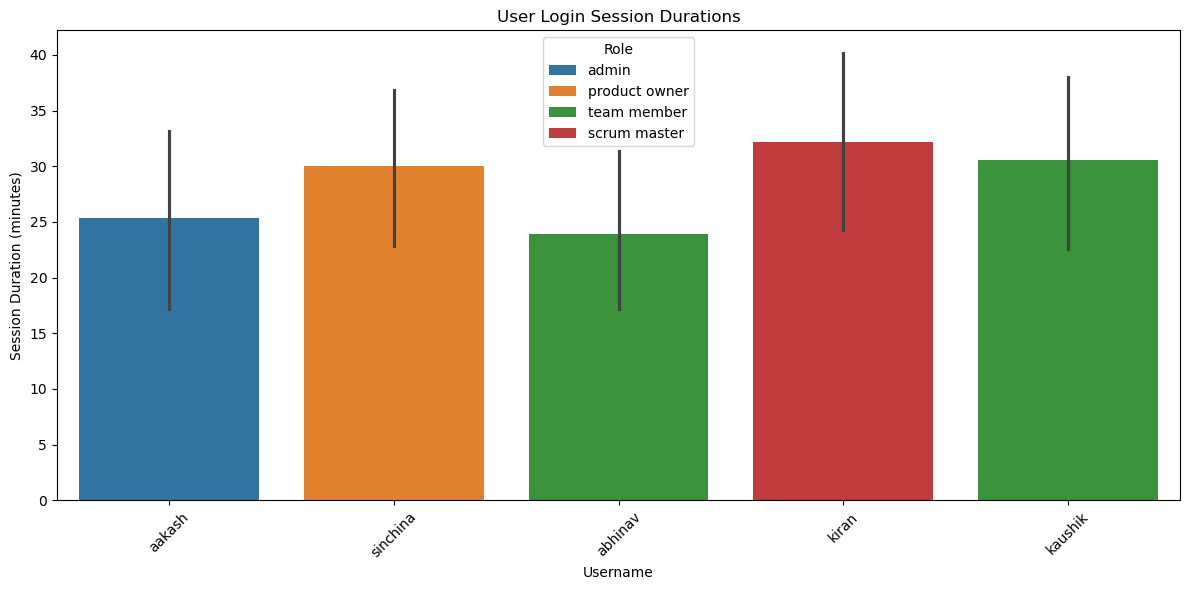

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Bar chart for session durations
plt.figure(figsize=(12, 6))
sns.barplot(data=session_df, x="Username", y="Session Duration (minutes)", hue="Role", dodge=False)
plt.title("User Login Session Durations")
plt.xlabel("Username")
plt.ylabel("Session Duration (minutes)")
plt.legend(title="Role")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Pie chart for role distribution


/tmp/ipykernel_4783/2900338088.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=session_sums, y=session_sums.index, palette="viridis")


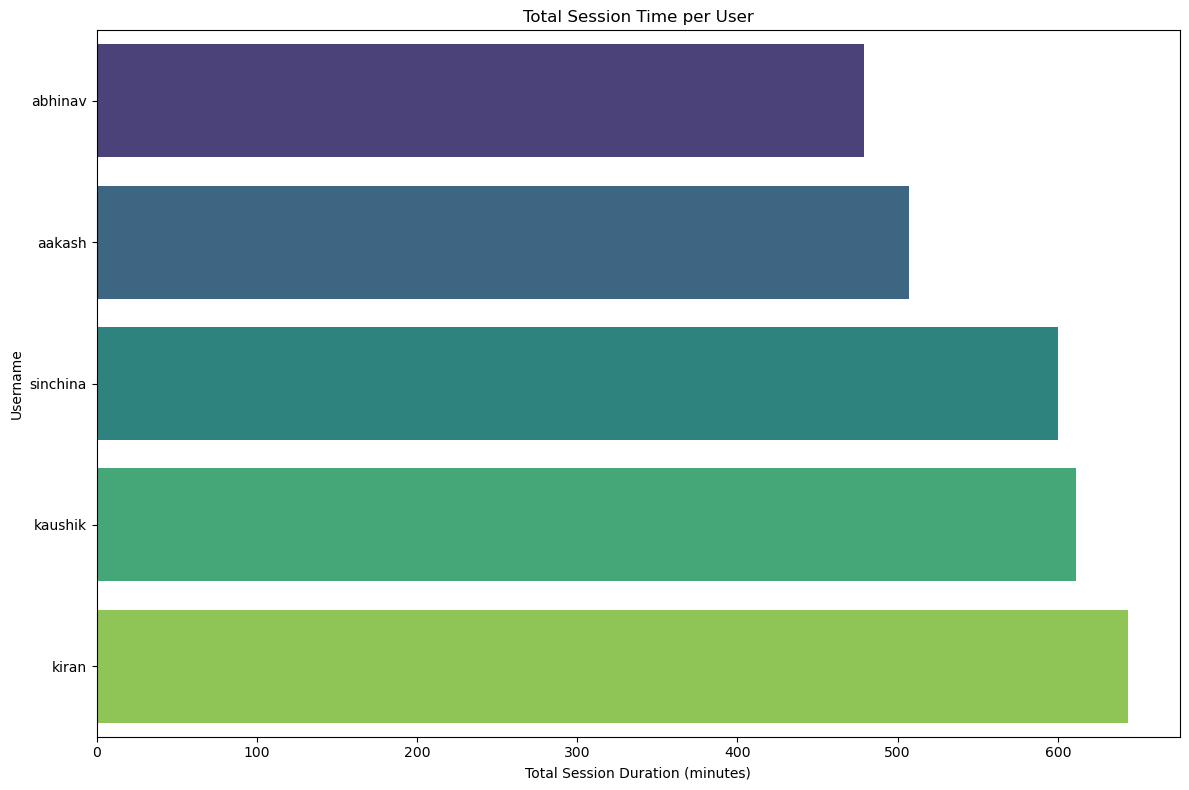

In [22]:
# Horizontal bar chart for session durations
plt.figure(figsize=(12, 8))
session_sums = session_df.groupby("Username")["Session Duration (minutes)"].sum().sort_values()
sns.barplot(x=session_sums, y=session_sums.index, palette="viridis")
plt.title("Total Session Time per User")
plt.xlabel("Total Session Duration (minutes)")
plt.ylabel("Username")
plt.tight_layout()
plt.show()


/tmp/ipykernel_4783/344114854.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=session_df, x="Role", y="Session Duration (minutes)", palette="Set2")


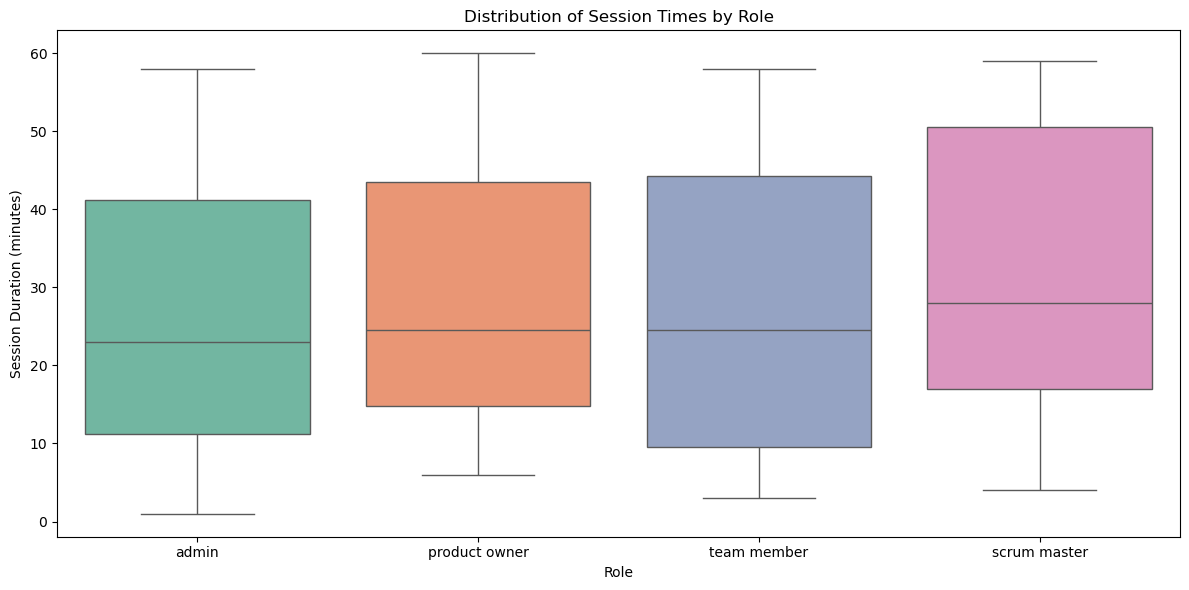

In [23]:
# Box plot for session durations by role
plt.figure(figsize=(12, 6))
sns.boxplot(data=session_df, x="Role", y="Session Duration (minutes)", palette="Set2")
plt.title("Distribution of Session Times by Role")
plt.xlabel("Role")
plt.ylabel("Session Duration (minutes)")
plt.tight_layout()
plt.show()


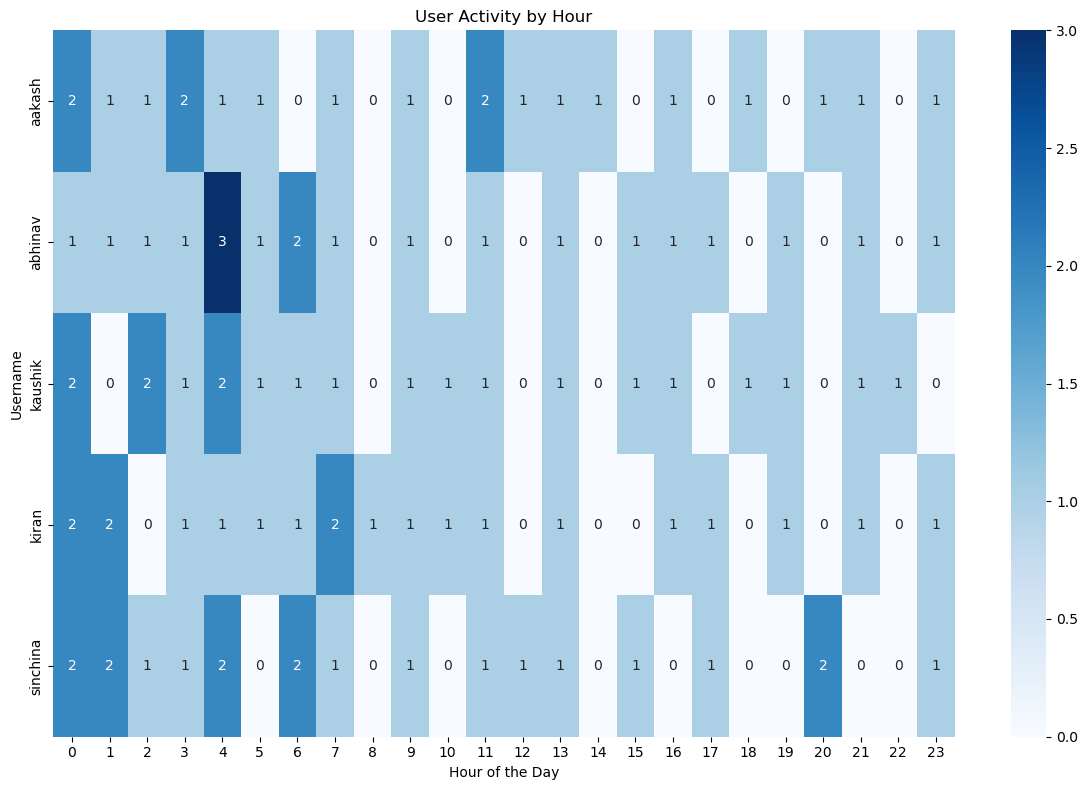

In [24]:
# Adding hour to the session data
session_df["Hour"] = session_df["Login Time"].dt.hour

# Heatmap of user activity
activity_counts = session_df.groupby(["Username", "Hour"]).size().unstack(fill_value=0)

plt.figure(figsize=(12, 8))
sns.heatmap(activity_counts, cmap="Blues", annot=True, fmt="d", cbar=True)
plt.title("User Activity by Hour")
plt.xlabel("Hour of the Day")
plt.ylabel("Username")
plt.tight_layout()
plt.show()


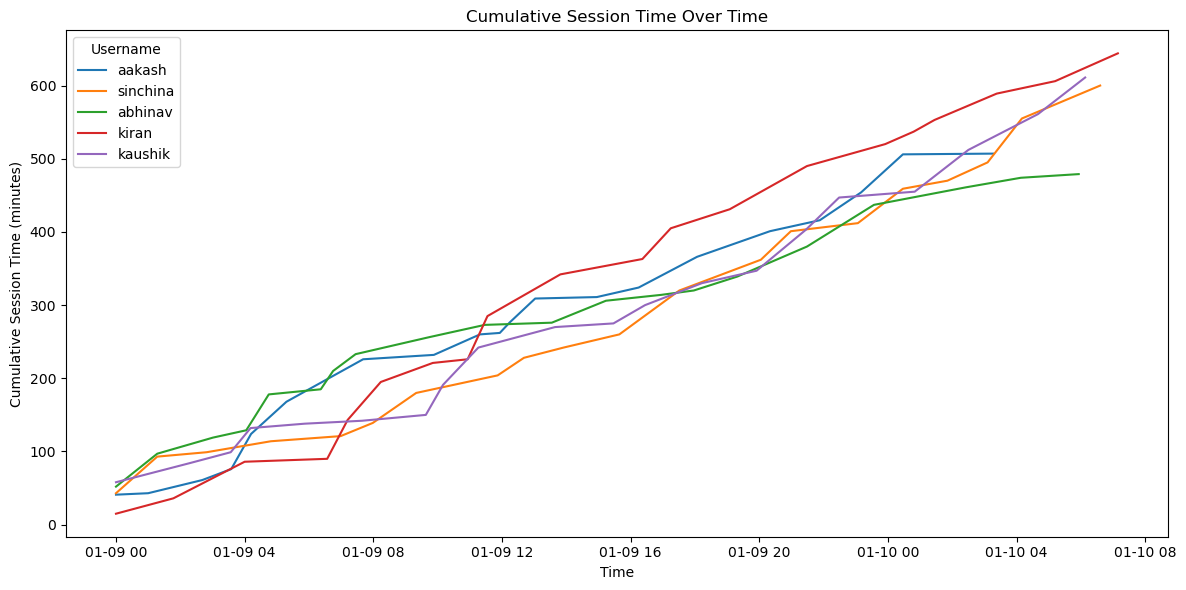

In [25]:
# Cumulative session time
session_df["Cumulative Time"] = session_df.groupby("Username")["Session Duration (minutes)"].cumsum()

plt.figure(figsize=(12, 6))
for username in session_df["Username"].unique():
    user_data = session_df[session_df["Username"] == username]
    plt.plot(user_data["Login Time"], user_data["Cumulative Time"], label=username)

plt.title("Cumulative Session Time Over Time")
plt.xlabel("Time")
plt.ylabel("Cumulative Session Time (minutes)")
plt.legend(title="Username")
plt.tight_layout()
plt.show()


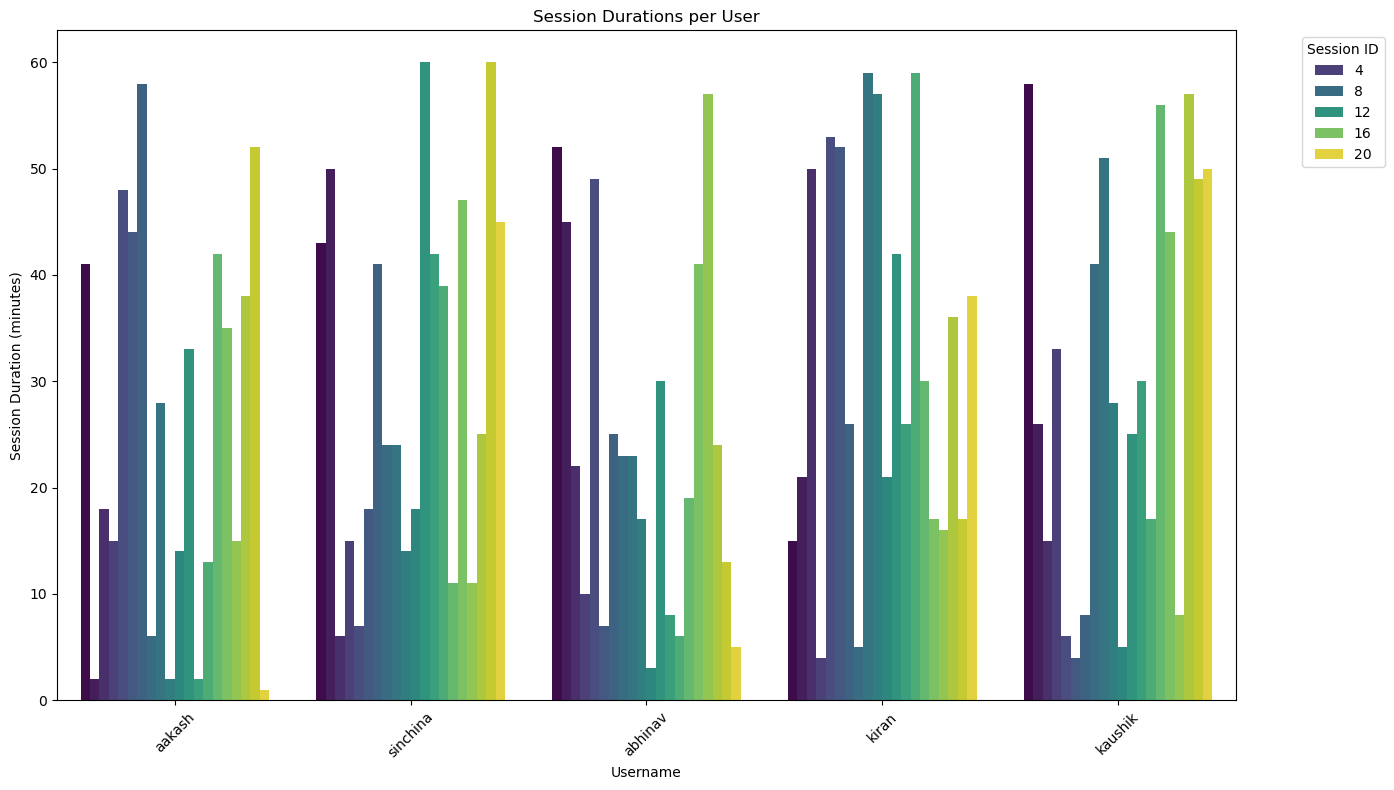